In [9]:
import os

In [48]:
%pwd

'c:\\Users\\Sandeep\\Desktop\\Projects\\AI-heart-murmur-detection'

In [11]:
os.chdir("../")

In [14]:
%pwd

'c:\\Users\\Sandeep\\Desktop\\Projects\\AI-heart-murmur-detection'

In [49]:
from dataclasses import dataclass
from pathlib import Path

@dataclass(frozen=True)
class ModelEvaluationConfig:
    root_dir: Path

    # Inputs
    transformed_data_path: Path
    trained_model_path: Path

    # Outputs
    metrics_path: Path
    confusion_matrix_path: Path

    # Evaluation
    batch_size: int

    # Model Architecture
    input_size: int
    hidden_size: int
    num_layers: int
    num_classes: int
    dropout: float

    # Labels
    classes: list[str]

In [50]:
from HeartBeat.constant import *
from HeartBeat.utils.common import read_yaml, create_directories

In [51]:
# 4 Update configuration manager

class configurationManager:
    def __init__(
        self,
        config_filepath = CONFIG_FILE_PATH,     # Access to constants
        params_filepath = PARAMS_FILE_PATH):

        self.config = read_yaml(config_filepath) # read all config and params yaml files
        self.params = read_yaml(params_filepath)

        create_directories([self.config.artifacts_root])

    def get_model_evaluation_config(self) -> ModelEvaluationConfig:

        config = self.config.model_evaluation

        create_directories([config.root_dir])

        return ModelEvaluationConfig(
            root_dir=Path(config.root_dir),

            transformed_data_path=Path(config.transformed_data_path),
            trained_model_path=Path(config.trained_model_path),

            metrics_path=Path(config.metrics_path),
            confusion_matrix_path=Path(config.confusion_matrix_path),

            batch_size=config.batch_size,

            input_size=config.input_size,
            hidden_size=config.hidden_size,
            num_layers=config.num_layers,
            num_classes=config.num_classes,
            dropout=config.dropout,

            classes=config.classes
        )

In [52]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader, TensorDataset
from HeartBeat.components.model_training import HeartMurmurLSTM

In [53]:
# model components
# 1) Load test data   2) create test loader       3) evaluate model

class model_evaluation:
    def __init__(self, config: ModelEvaluationConfig):
        self.config = config

    def load_test_data(self):
        path = self.config.transformed_data_path

        X_test = np.load(path / "X_test.npy")
        y_test = np.load(path / "y_test.npy")

        return X_test, y_test
    
    def create_test_loader(self, X_test, y_test):

        X_test = torch.tensor(X_test, dtype=torch.float32)
        y_test = torch.tensor(y_test, dtype=torch.float32)

        dataset = TensorDataset(X_test, y_test)

        return DataLoader(
            dataset,
            batch_size=self.config.batch_size,
            shuffle=False
        )
    
    def load_model(self):
        """
        Load the trained Heart Murmur LSTM model.
        """

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        model = HeartMurmurLSTM(self.config)

        model.load_state_dict(
            torch.load(
                self.config.trained_model_path,
                map_location=device
            )
        )

        model.to(device)

        print(f"✓ Model loaded successfully from {self.config.trained_model_path}")

        return model

    def evaluate_model(self, model, test_loader):

        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        model.to(device)
        model.eval()

        all_preds = []
        all_labels = []

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                preds = outputs.argmax(dim=1).cpu().numpy()
                labels = y_batch.argmax(dim=1).cpu().numpy()

                all_preds.extend(preds)
                all_labels.extend(labels)

        # Classification report
        report = classification_report(
            all_labels,
            all_preds,
            target_names=self.config.classes,
            output_dict=True
        )

        print(classification_report(
            all_labels,
            all_preds,
            target_names=self.config.classes
        ))

        # Save metrics
        metrics_df = pd.DataFrame(report).transpose()

        os.makedirs(os.path.dirname(self.config.metrics_path), exist_ok=True)
        metrics_df.to_csv(self.config.metrics_path, index=True)

        print(f"Metrics saved to {self.config.metrics_path}")

        # Confusion Matrix
        cm = confusion_matrix(all_labels, all_preds)

        plt.figure(figsize=(8, 6))
        sns.heatmap(
            cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=self.config.classes,
            yticklabels=self.config.classes
        )

        plt.title("Confusion Matrix")
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.tight_layout()
        plt.show()
        plt.savefig(self.config.confusion_matrix_path)
        plt.close()

        return all_preds, all_labels

[2026-06-26 23:26:44,658: INFO: common: ymal file config\config.yaml loaded sucessfully]
[2026-06-26 23:26:44,661: INFO: common: ymal file params.yaml loaded sucessfully]
[2026-06-26 23:26:44,663: INFO: common: created directory at artifacts]
[2026-06-26 23:26:44,665: INFO: common: created directory at artifacts/model_evaluation]
✓ Model loaded successfully from artifacts\model_training\heart_murmur_model.pth
              precision    recall  f1-score   support

    artifact       1.00      0.06      0.12        32
      murmur       0.00      0.00      0.00        75
      normal       0.70      1.00      0.82       244

    accuracy                           0.70       351
   macro avg       0.57      0.35      0.31       351
weighted avg       0.58      0.70      0.58       351



c:\Users\Sandeep\anaconda3\envs\heart\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sandeep\anaconda3\envs\heart\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Sandeep\anaconda3\envs\heart\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

Metrics saved to artifacts\model_evaluation\metrics.csv


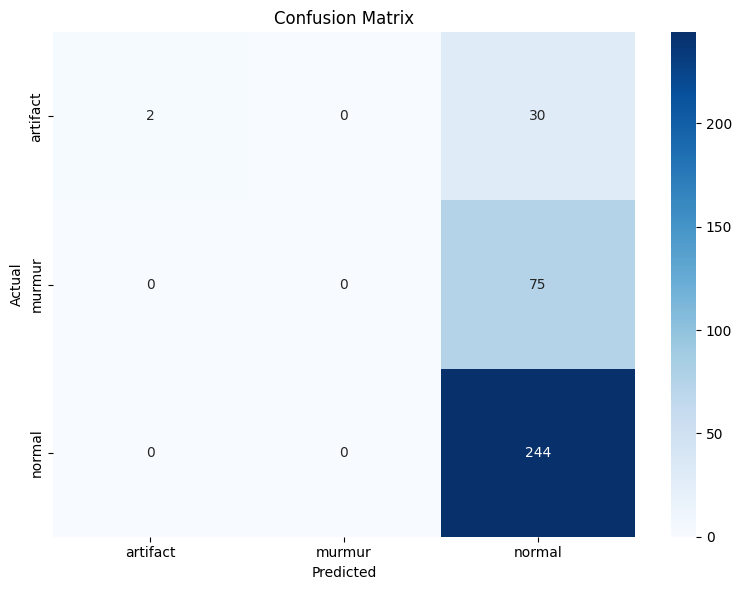

✓ Model evaluation completed successfully.


In [54]:
try:
    config = configurationManager()
    evaluation_config = config.get_model_evaluation_config()

    # Initialize evaluation component
    evaluation = model_evaluation(evaluation_config)

    # Load model
    model = evaluation.load_model()

    # Load test data
    X_test, y_test = evaluation.load_test_data()

    # Create DataLoader
    test_loader = evaluation.create_test_loader(
        X_test,
        y_test
    )

    # Evaluate
    evaluation.evaluate_model(
        model=model,
        test_loader=test_loader
    )

    print("✓ Model evaluation completed successfully.")

except Exception as e:
    raise e